# MEDALLIO — CEO 5-MINUTE AI BRIEFING
## Extreme-value executive notebook

**Objetivo:** que un CEO con muy poco tiempo entienda en menos de 5 minutos:

1. **Qué cambió.**
2. **Cuánto dinero está en juego.**
3. **Dónde está el riesgo.**
4. **Qué decisión debe tomar hoy.**
5. **Qué tan confiable es la evidencia.**
6. **Qué iniciativa de IA escalar, vigilar o detener.**

Este notebook **no compite con Power BI**.  
Es la capa ejecutiva superior: **menos métricas, más decisiones**.

---

## Estructura de lectura

### 00 — CEO Signal
Una sola pantalla con el pulso de Medallio.

### 01 — Value at Stake
Cuánto valor económico está potencialmente en juego.

### 02 — What Changed
Qué cambió comercialmente desde el último corte.

### 03 — Forecast Confidence
Qué creemos que ocurrirá y cuánta confianza tenemos.

### 04 — Decision Queue
Las 3–5 decisiones con mayor valor esperado.

### 05 — AI Portfolio
Qué escalar, qué vigilar, qué detener.

### 06 — CEO Ask
Qué necesita aprobar o decidir Dirección.

> **Principio:** ningún gráfico entra si no cambia una decisión.

# 0. Setup
Ejecuta desde:

```powershell
cd C:\Projects\bd_replica_crm
.\.venv\Scripts\Activate.ps1
python -m jupyter lab
```

In [1]:
from __future__ import annotations

import os, re, json, math, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RUN_TS = datetime.now(timezone.utc)
ARTIFACT_DIR = Path("artifacts") / "medallio_ceo_briefing"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("CEO Briefing run:", RUN_TS.isoformat())

CEO Briefing run: 2026-10-08T16:36:48.985188+00:00


In [2]:
def find_repo_root(start=None):
    p = (Path(start) if start else Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / ".git").exists() or (candidate / ".env.example").exists():
            return candidate
    return p

ROOT = find_repo_root()
ENV_PATH = ROOT / ".env"

def load_dotenv_minimal(path):
    if not path.exists():
        return
    for raw in path.read_text(encoding="utf-8").splitlines():
        raw = raw.strip()
        if not raw or raw.startswith("#") or "=" not in raw:
            continue
        k, v = raw.split("=", 1)
        os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

load_dotenv_minimal(ENV_PATH)

DB_CONFIG = {
    "host": os.getenv("POSTGRES_HOST", "localhost"),
    "port": int(os.getenv("POSTGRES_PORT", "5432")),
    "dbname": os.getenv("POSTGRES_DATABASE", "medallio_dw"),
    "user": os.getenv("POSTGRES_USER", "postgres"),
    "password": os.getenv("POSTGRES_PASSWORD", ""),
    "connect_timeout": int(os.getenv("POSTGRES_CONNECT_TIMEOUT", "10")),
}

In [3]:
import psycopg

FORBIDDEN_SQL = re.compile(
    r"\b(insert|update|delete|drop|alter|truncate|create|grant|revoke|copy|call|do)\b",
    flags=re.I,
)

def get_conn():
    return psycopg.connect(**DB_CONFIG)

def query_df(sql, params=None, read_only=True):
    statement = sql.strip().rstrip(";")
    if read_only and FORBIDDEN_SQL.search(statement):
        raise ValueError("CEO notebook is read-only.")
    with get_conn() as conn:
        with conn.cursor() as cur:
            cur.execute(statement, params or ())
            cols = [d.name for d in cur.description] if cur.description else []
            rows = cur.fetchall() if cur.description else []
    return pd.DataFrame(rows, columns=cols)

def safe_relation(name):
    if not re.fullmatch(r"[A-Za-z_][A-Za-z0-9_]*\.[A-Za-z_][A-Za-z0-9_]*", name):
        raise ValueError(name)
    return name

def relation_exists(name):
    schema, rel = safe_relation(name).split(".", 1)
    q = """
    SELECT EXISTS (
        SELECT 1 FROM information_schema.tables
        WHERE table_schema=%s AND table_name=%s
        UNION ALL
        SELECT 1 FROM information_schema.views
        WHERE table_schema=%s AND table_name=%s
    ) AS ok
    """
    return bool(query_df(q, (schema, rel, schema, rel)).iloc[0,0])

def fetch(rel, limit=300000):
    try:
        if relation_exists(rel):
            return query_df(f"SELECT * FROM {safe_relation(rel)} LIMIT {int(limit)}")
    except Exception:
        pass
    return pd.DataFrame()

print(query_df("SELECT current_database() AS db, now() AS postgres_now"))

            db                     postgres_now
0  medallio_dw 2026-10-08 11:36:49.520677-05:00


# 1. Visual engine — CEO only

In [4]:
def card_grid(items, cols=4):
    cards=[]
    for label,value,detail in items:
        cards.append(
            "<div style='border:1px solid rgba(127,127,127,.26);border-radius:14px;"
            "padding:15px 16px;min-height:86px'>"
            f"<div style='font-size:12px;opacity:.65'>{label}</div>"
            f"<div style='font-size:29px;font-weight:780;margin:4px 0'>{value}</div>"
            f"<div style='font-size:11px;opacity:.62'>{detail}</div>"
            "</div>"
        )
    display(HTML(
        f"<div style='display:grid;grid-template-columns:repeat({cols},minmax(0,1fr));gap:10px'>"
        + "".join(cards) + "</div>"
    ))

def title(text, subtitle=None):
    sub = f"<div style='font-size:13px;opacity:.7'>{subtitle}</div>" if subtitle else ""
    display(HTML(f"<div style='margin:22px 0 12px'><div style='font-size:27px;font-weight:800'>{text}</div>{sub}</div>"))

def fmt_pct(x):
    return "N/D" if pd.isna(x) else f"{x:.1f}%"

def fmt_num(x):
    if x is None or (isinstance(x,float) and np.isnan(x)):
        return "N/D"
    x=float(x)
    if abs(x)>=1_000_000: return f"{x/1_000_000:.1f}M"
    if abs(x)>=1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

def fmt_money(x):
    if x is None or (isinstance(x,float) and np.isnan(x)):
        return "N/D"
    x=float(x)
    if abs(x)>=1_000_000: return f"S/ {x/1_000_000:.1f}M"
    if abs(x)>=1_000: return f"S/ {x/1_000:.0f}K"
    return f"S/ {x:,.0f}"

def find_col(df, candidates):
    if df is None or not len(df): return None
    lower={c.lower():c for c in df.columns}
    for x in candidates:
        if x.lower() in lower: return lower[x.lower()]
    for x in candidates:
        for c in df.columns:
            if x.lower() in c.lower(): return c
    return None

def finish(name=None):
    plt.tight_layout()
    if name:
        plt.savefig(ARTIFACT_DIR/name, dpi=160, bbox_inches="tight")
    plt.show()

# 2. Snapshot — Medallio in one pass

In [5]:
EVENTS = fetch("analytics.fact_evento_comercial")
SEASON = fetch("features.v_estacionalidad_panel")
ML = fetch("features.v_dataset_unidad_entrenamiento")
FC = fetch("analytics.v_commercial_forecast_current")
PERF = fetch("analytics.v_commercial_forecast_performance")
MON = fetch("analytics.v_commercial_forecast_monitoring")
ACTIONS = fetch("decision_intelligence.commercial_forecast_actions")
GOALS = fetch("decision_intelligence.commercial_forecast_goals")
OUTCOMES = fetch("analytics.commercial_forecast_outcomes")
RUNS = fetch("model_control.commercial_forecast_runs")

CORE_OBJECTS = [
    "analytics.fact_evento_comercial",
    "analytics.snapshot_unidad_diario",
    "analytics.historial_oferta_unidad",
    "analytics.historial_etapa_proyecto",
    "features.v_estacionalidad_panel",
    "features.v_dataset_unidad_entrenamiento",
    "analytics.v_commercial_forecast_current",
    "analytics.v_commercial_forecast_performance",
    "analytics.v_commercial_forecast_monitoring",
    "decision_intelligence.commercial_forecast_actions",
    "analytics.commercial_forecast_outcomes",
]
availability = pd.DataFrame({
    "object":CORE_OBJECTS,
    "available":[relation_exists(x) for x in CORE_OBJECTS]
})

# 00 — CEO SIGNAL
## La pantalla que sí debería mirar un CEO

In [6]:
coverage = availability["available"].mean()*100

wape = bias = np.nan
mature = 0
if len(PERF):
    ac = find_col(PERF, ["actual","real","y_actual"])
    pc = find_col(PERF, ["prediction","forecast","prediccion","y_pred"])
    if ac and pc:
        a=pd.to_numeric(PERF[ac],errors="coerce")
        p=pd.to_numeric(PERF[pc],errors="coerce")
        m=a.notna() & p.notna()
        mature=int(m.sum())
        if mature:
            wape=float((a[m]-p[m]).abs().sum()/max(a[m].abs().sum(),1e-9)*100)
            bias=float((p[m]-a[m]).mean())

pending_actions=len(ACTIONS)
status_col=find_col(ACTIONS,["status","estado"]) if len(ACTIONS) else None
if status_col:
    pending_actions=int((~ACTIONS[status_col].astype("string").str.lower()
        .isin(["done","closed","completed","completado","cerrado"])).sum())

risk_alerts=0
if len(MON):
    text=MON.astype("string").apply(lambda s:s.str.lower())
    risk_alerts=int(text.apply(lambda s:s.str.contains("drift|alert|red|degrad",regex=True,na=False)).any(axis=1).sum())

title("CEO Signal", "Valor · riesgo · confianza · acción")

card_grid([
    ("Plataforma lista", fmt_pct(coverage), "objetos core disponibles"),
    ("Forecast WAPE", fmt_pct(wape), "error ponderado"),
    ("Bias forecast", f"{bias:+.2f}" if pd.notna(bias) else "N/D", "sobre/sub predicción"),
    ("Acciones abiertas", fmt_num(pending_actions), "requieren owner"),
    ("Alertas de riesgo", fmt_num(risk_alerts), "drift / degradación"),
    ("Outcomes", fmt_num(len(OUTCOMES)), "aprendizaje real"),
], cols=3)

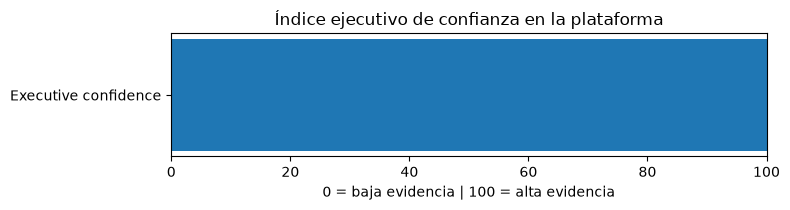

In [7]:
# CEO confidence gauge: one composite, transparent and simple
components = []

if pd.notna(coverage): components.append(min(max(coverage,0),100))
if pd.notna(wape): components.append(max(0,100-min(wape,100)))
if len(OUTCOMES): components.append(min(len(OUTCOMES)*5,100))
if pending_actions == 0: components.append(100)
elif pending_actions < 5: components.append(80)
elif pending_actions < 15: components.append(60)
else: components.append(40)

confidence = float(np.mean(components)) if components else np.nan

fig, ax = plt.subplots(figsize=(8,2.2))
ax.barh(["Executive confidence"], [confidence if pd.notna(confidence) else 0])
ax.set_xlim(0,100)
ax.set_xlabel("0 = baja evidencia | 100 = alta evidencia")
ax.set_title("Índice ejecutivo de confianza en la plataforma")
finish("00_ceo_confidence.png")

# 01 — VALUE AT STAKE
## El CEO necesita saber dinero, no solamente métricas

In [8]:
# Detectar columnas monetarias / impacto si existen
value_candidates=[]
for df_name,df in [("OUTCOMES",OUTCOMES),("ACTIONS",ACTIONS),("GOALS",GOALS),("FC",FC)]:
    if len(df):
        for c in df.select_dtypes(include=np.number).columns:
            if any(k in c.lower() for k in ["impact","value","valor","monto","revenue","benefit","gap","shortfall"]):
                value_candidates.append((df_name,c))

observed_value=np.nan
value_source=None
if value_candidates:
    df_name,c=value_candidates[0]
    src=globals()[df_name]
    observed_value=float(pd.to_numeric(src[c],errors="coerce").sum())
    value_source=f"{df_name}.{c}"

title("Value at Stake", "Cuánto valor económico está visible hoy")

card_grid([
    ("Valor observable", fmt_money(observed_value), value_source or "sin campo monetario consolidado"),
    ("Outcomes medidos", fmt_num(len(OUTCOMES)), "decisiones con resultado"),
    ("Metas activas", fmt_num(len(GOALS)), "objetivos registrados"),
    ("Forecasts vigentes", fmt_num(len(FC)), "señales prospectivas"),
], cols=4)

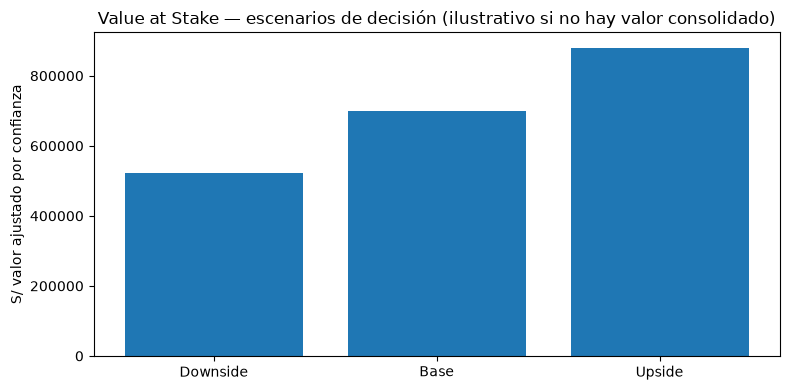

,scenario,uplift_pct,confidence_pct,value,risk_adjusted_value
0,Downside,-5,55,"950,000.000","522,500.000"
1,Base,0,70,"1,000,000.000","700,000.000"
2,Upside,10,80,"1,100,000.000","880,000.000"


In [9]:
# Scenario value ladder — explicit illustrative assumptions
scenario = pd.DataFrame({
    "scenario":["Downside","Base","Upside"],
    "uplift_pct":[-5,0,10],
    "confidence_pct":[55,70,80]
})

base_value = observed_value if pd.notna(observed_value) and observed_value != 0 else 1_000_000
scenario["value"] = base_value*(1+scenario["uplift_pct"]/100)
scenario["risk_adjusted_value"] = scenario["value"]*scenario["confidence_pct"]/100

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(scenario["scenario"], scenario["risk_adjusted_value"])
ax.set_ylabel("S/ valor ajustado por confianza")
ax.set_title("Value at Stake — escenarios de decisión (ilustrativo si no hay valor consolidado)")
finish("01_value_at_stake.png")
display(scenario)

# 02 — WHAT CHANGED
## Qué cambió desde el periodo anterior

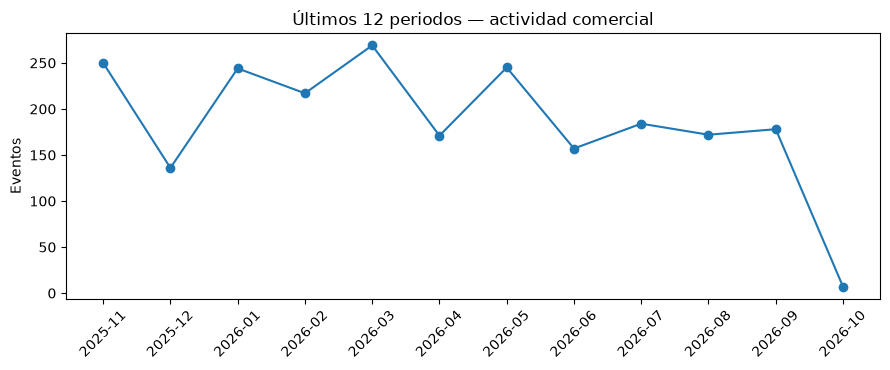

In [10]:
title("What Changed", "La conversación ejecutiva debe comenzar por delta, no por nivel")

if len(EVENTS):
    date_col=find_col(EVENTS,["fecha_evento","fecha","fecha_inicio","created_at","captured_at"])
    if date_col:
        tmp=EVENTS.copy()
        tmp["_date"]=pd.to_datetime(tmp[date_col],errors="coerce")
        tmp=tmp.dropna(subset=["_date"])
        if len(tmp):
            monthly=tmp.groupby(tmp["_date"].dt.to_period("M")).size().sort_index()
            if len(monthly)>=2:
                curr=float(monthly.iloc[-1]); prev=float(monthly.iloc[-2])
                delta=(curr-prev)/max(prev,1)*100
                card_grid([
                    ("Último mes", fmt_num(curr), str(monthly.index[-1])),
                    ("Mes anterior", fmt_num(prev), str(monthly.index[-2])),
                    ("Cambio", f"{delta:+.1f}%", "actividad comercial observada"),
                ], cols=3)

                fig,ax=plt.subplots(figsize=(9,3.8))
                tail=monthly.tail(12)
                ax.plot(tail.index.astype(str),tail.values,marker="o")
                ax.set_title("Últimos 12 periodos — actividad comercial")
                ax.set_ylabel("Eventos")
                ax.tick_params(axis="x",rotation=45)
                finish("02_what_changed.png")
            else:
                display(Markdown("**No hay al menos dos periodos comparables todavía.**"))
    else:
        display(Markdown("**No se detectó columna temporal en `fact_evento_comercial`.**"))
else:
    display(Markdown("**`fact_evento_comercial` aún no está disponible.**"))

# 03 — FORECAST CONFIDENCE
## ¿Qué creemos que ocurrirá y cuánta confianza merece?

In [11]:
title("Forecast Confidence", "Precisión · sesgo · maduración · horizonte")

card_grid([
    ("Pronósticos actuales", fmt_num(len(FC)), "emisiones vigentes"),
    ("Resultados maduros", fmt_num(mature), "observaciones evaluables"),
    ("WAPE", fmt_pct(wape), "menor es mejor"),
    ("Bias", f"{bias:+.2f}" if pd.notna(bias) else "N/D", "ideal cercano a cero"),
], cols=4)

In [12]:
if len(PERF):
    ac=find_col(PERF,["actual","real","y_actual"])
    pc=find_col(PERF,["prediction","forecast","prediccion","y_pred"])
    if ac and pc:
        a=pd.to_numeric(PERF[ac],errors="coerce")
        p=pd.to_numeric(PERF[pc],errors="coerce")
        m=a.notna()&p.notna()
        if m.any():
            fig,ax=plt.subplots(figsize=(6,6))
            ax.scatter(a[m],p[m],alpha=.5)
            lo=min(a[m].min(),p[m].min()); hi=max(a[m].max(),p[m].max())
            ax.plot([lo,hi],[lo,hi],linestyle="--")
            ax.set_xlabel("Real")
            ax.set_ylabel("Forecast")
            ax.set_title("Confianza visual — Real vs Forecast")
            finish("03_forecast_confidence.png")

# 04 — CEO DECISION QUEUE
## Sólo las decisiones que merecen tiempo de CEO

In [13]:
decisions=[]

if pd.notna(wape) and wape>25:
    decisions.append({
        "decision":"Revisar confiabilidad del forecast",
        "value_at_stake":"Planificación / metas",
        "confidence":"Alta",
        "urgency":"Hoy",
        "owner":"Data Science + Comercial",
        "why":f"WAPE={wape:.1f}%"
    })

if risk_alerts>0:
    decisions.append({
        "decision":"Resolver alertas de drift / degradación",
        "value_at_stake":"Riesgo de decisión",
        "confidence":"Alta",
        "urgency":"Hoy",
        "owner":"AI Governance",
        "why":f"{risk_alerts} alertas"
    })

if pending_actions>10:
    decisions.append({
        "decision":"Desbloquear backlog de acciones",
        "value_at_stake":"Velocidad de ejecución",
        "confidence":"Media",
        "urgency":"Esta semana",
        "owner":"Product Owner",
        "why":f"{pending_actions} acciones abiertas"
    })

if coverage<90:
    decisions.append({
        "decision":"Completar capacidades críticas de Medallio",
        "value_at_stake":"Escalabilidad IA",
        "confidence":"Alta",
        "urgency":"Este mes",
        "owner":"Data & AI",
        "why":f"Cobertura={coverage:.0f}%"
    })

if not decisions:
    decisions.append({
        "decision":"Mantener rumbo y exigir evidencia de valor",
        "value_at_stake":"Escala",
        "confidence":"Media",
        "urgency":"Próximo comité",
        "owner":"AI Steering Committee",
        "why":"Sin alertas ejecutivas automáticas"
    })

decision_df=pd.DataFrame(decisions)
display(decision_df.head(5).style.hide(axis="index"))

decision,value_at_stake,confidence,urgency,owner,why
Mantener rumbo y exigir evidencia de valor,Escala,Media,Próximo comité,AI Steering Committee,Sin alertas ejecutivas automáticas


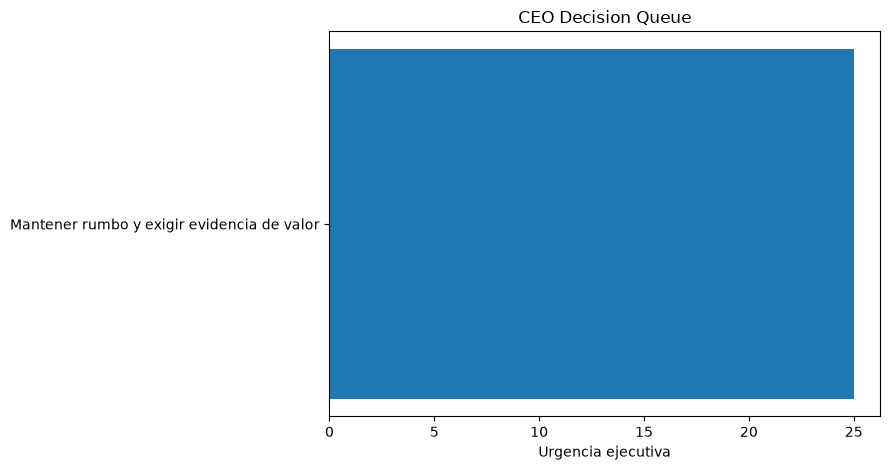

In [14]:
priority_map={"Hoy":100,"Esta semana":75,"Este mes":50,"Próximo comité":25}
plot=decision_df.copy()
plot["priority"]=plot["urgency"].map(priority_map).fillna(20)
plot=plot.sort_values("priority")

fig,ax=plt.subplots(figsize=(9,4.8))
ax.barh(plot["decision"],plot["priority"])
ax.set_xlabel("Urgencia ejecutiva")
ax.set_title("CEO Decision Queue")
finish("04_ceo_decision_queue.png")

# 05 — AI PORTFOLIO: SCALE / WATCH / STOP
## El CEO debe administrar apuestas, no algoritmos

In [15]:
portfolio=pd.DataFrame([
    ["Forecast comercial",9,8,7],
    ["Lead scoring",8,7,6],
    ["Stock risk",8,8,5],
    ["Pricing elasticity",9,5,8],
    ["Anomaly detection",6,9,3],
    ["Next best action",9,4,8],
],columns=["initiative","business_value","readiness","risk"])

portfolio["portfolio_score"]=portfolio["business_value"]*portfolio["readiness"]/(portfolio["risk"]+1)

def classify(r):
    if r["portfolio_score"]>=10 and r["readiness"]>=7:
        return "SCALE"
    if r["portfolio_score"]>=6:
        return "WATCH / BUILD"
    return "STOP / REFRAME"

portfolio["CEO_decision"]=portfolio.apply(classify,axis=1)
display(portfolio.sort_values("portfolio_score",ascending=False).style.hide(axis="index"))

initiative,business_value,readiness,risk,portfolio_score,CEO_decision
Anomaly detection,6,9,3,13.500000,SCALE
Stock risk,8,8,5,10.666667,SCALE
Forecast comercial,9,8,7,9.000000,WATCH / BUILD
Lead scoring,8,7,6,8.000000,WATCH / BUILD
Pricing elasticity,9,5,8,5.000000,STOP / REFRAME
Next best action,9,4,8,4.000000,STOP / REFRAME


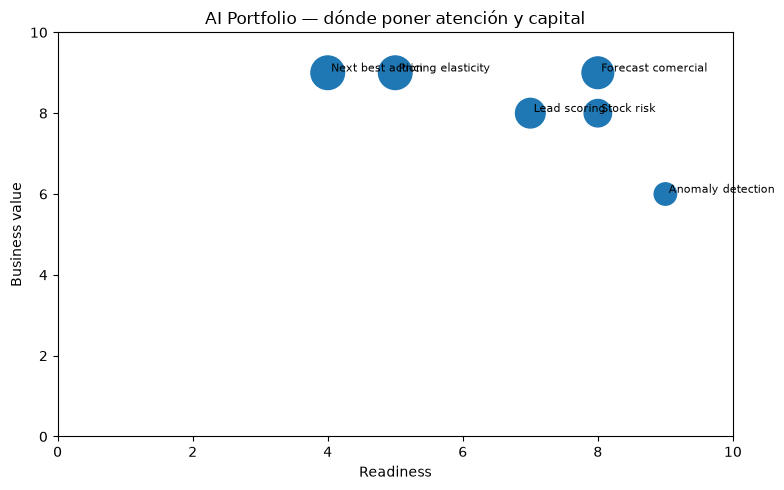

In [16]:
fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(
    portfolio["readiness"],
    portfolio["business_value"],
    s=(portfolio["risk"]+1)*65
)
for _,r in portfolio.iterrows():
    ax.text(r["readiness"]+.05,r["business_value"]+.03,r["initiative"],fontsize=8)
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.set_xlabel("Readiness")
ax.set_ylabel("Business value")
ax.set_title("AI Portfolio — dónde poner atención y capital")
finish("05_ai_portfolio.png")

# 06 — TRUST BEFORE SCALE
## Antes de escalar IA: ¿tenemos evidencia suficiente?

In [17]:
trust = pd.DataFrame([
    ["Data available", coverage>=90],
    ["Forecast evaluated", mature>=10],
    ["Forecast acceptable", pd.notna(wape) and wape<=25],
    ["Low drift risk", risk_alerts==0],
    ["Outcome loop exists", len(OUTCOMES)>0],
    ["Decision ownership visible", pending_actions<10],
],columns=["control","pass"])

trust_score=trust["pass"].mean()*100
title("Trust before Scale", "Ninguna IA crítica debería escalar sin estas señales")
card_grid([
    ("Trust score", fmt_pct(trust_score), "controles ejecutivos mínimos"),
    ("Controles OK", f"{int(trust['pass'].sum())}/{len(trust)}", "evidence gates"),
],cols=2)

display(trust.style.hide(axis="index"))

control,pass
Data available,True
Forecast evaluated,False
Forecast acceptable,False
Low drift risk,True
Outcome loop exists,False
Decision ownership visible,True


# 07 — CEO ASK
## Qué debería decidir hoy

In [18]:
asks=[]

if coverage<90:
    asks.append("Aprobar completar la capa de datos / contratos antes de escalar nuevos casos de IA.")
if pd.notna(wape) and wape>25:
    asks.append("Exigir challenger y revisión del forecast antes de usarlo como base de metas.")
if risk_alerts>0:
    asks.append("Pausar promoción automática de modelos con drift hasta revisión.")
if len(OUTCOMES)==0:
    asks.append("Hacer obligatorio capturar outcome y ROI de cada decisión asistida por IA.")
if not asks:
    asks.append("Escalar solamente iniciativas con evidencia de valor y mantener revisión mensual de riesgo.")

html="<ol style='font-size:17px;line-height:1.55'>"
for a in asks[:3]:
    html+=f"<li>{a}</li>"
html+="</ol>"
display(HTML(html))

# 08 — BOARD SLIDE IN ONE CELL
## Copiar directamente a comité

In [19]:
board_summary = {
    "headline": (
        "Medallio está listo para escalar con disciplina"
        if coverage>=90 and (pd.isna(wape) or wape<=25)
        else "Medallio tiene valor, pero aún requiere cerrar brechas críticas"
    ),
    "platform_coverage_pct": round(float(coverage),1),
    "forecast_wape_pct": None if pd.isna(wape) else round(float(wape),1),
    "forecast_bias": None if pd.isna(bias) else round(float(bias),2),
    "open_actions": int(pending_actions),
    "risk_alerts": int(risk_alerts),
    "outcomes": int(len(OUTCOMES)),
    "trust_score_pct": round(float(trust_score),1),
    "top_3_decisions": decision_df.head(3).to_dict("records"),
    "ceo_asks": asks[:3],
}

print(json.dumps(board_summary,indent=2,ensure_ascii=False,default=str))

{
  "headline": "Medallio está listo para escalar con disciplina",
  "platform_coverage_pct": 100.0,
  "forecast_wape_pct": null,
  "forecast_bias": null,
  "open_actions": 0,
  "risk_alerts": 0,
  "outcomes": 0,
  "trust_score_pct": 50.0,
  "top_3_decisions": [
    {
      "decision": "Mantener rumbo y exigir evidencia de valor",
      "value_at_stake": "Escala",
      "confidence": "Media",
      "urgency": "Próximo comité",
      "owner": "AI Steering Committee",
      "why": "Sin alertas ejecutivas automáticas"
    }
  ],
  "ceo_asks": [
    "Hacer obligatorio capturar outcome y ROI de cada decisión asistida por IA."
  ]
}


# 09 — Export CEO Pack

In [20]:
decision_df.to_csv(ARTIFACT_DIR/"ceo_decision_queue.csv",index=False)
portfolio.to_csv(ARTIFACT_DIR/"ai_portfolio_scale_watch_stop.csv",index=False)
trust.to_csv(ARTIFACT_DIR/"trust_before_scale.csv",index=False)

(ARTIFACT_DIR/"board_summary.json").write_text(
    json.dumps(board_summary,indent=2,ensure_ascii=False,default=str),
    encoding="utf-8"
)

print("CEO Pack:", ARTIFACT_DIR.resolve())
for p in sorted(ARTIFACT_DIR.glob("*")):
    print(" -",p.name)

CEO Pack: C:\projects\bd_replica_crm\notebooks\artifacts\medallio_ceo_briefing
 - 00_ceo_confidence.png
 - 01_value_at_stake.png
 - 02_what_changed.png
 - 04_ceo_decision_queue.png
 - 05_ai_portfolio.png
 - ai_portfolio_scale_watch_stop.csv
 - board_summary.json
 - ceo_decision_queue.csv
 - trust_before_scale.csv


# Final: la regla de diseño

Un CEO con poco tiempo no necesita 40 indicadores.

Necesita ver:

> **VALUE → RISK → CONFIDENCE → DECISION → OWNER → OUTCOME**

Todo lo demás debe quedar detrás como evidencia.

Este notebook puede convivir con la Control Tower anterior:

- **CEO 5-Minute Briefing:** dirección general.
- **AI Control Tower:** dirección de IA / Analytics.
- **Power BI:** consumo operativo recurrente.
- **Medallio DW:** sistema de registro y aprendizaje.